In [1]:
import numpy as np
import requests
import json
import pandas as pd
import os
import folium
from folium import plugins

In [2]:
print(folium.__version__)

0.20.0


In [3]:
# pole 데이터

elec_df = pd.read_csv("gangwon_poles_4326.csv")
elec_df

,pole_id,lon,lat
0,0,127.618392,37.732192
1,1,127.617858,37.732002
2,2,127.617349,37.731836
3,3,127.616804,37.731666
4,4,127.616286,37.731509
...,...,...,...
1387826,1387826,128.716098,38.024719
1387827,1387827,128.716515,38.024432
1387828,1387828,128.716938,38.024129
1387829,1387829,128.717348,38.023796


# 지도 시각화

In [4]:
# 강원도 행정구역 경계(geojson) 생성

import folium
import json

m = folium.Map(
    location=[37.8228, 128.1555],
    zoom_start=8,
)

# 강원도 경계 추가
with open('gangwon.geojson', encoding='utf-8') as f:
    geojson_data = json.load(f)

folium.GeoJson(
    geojson_data,
    name='강원도 경계',
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'blue',
        'weight': 2
    }
).add_to(m)

#m

In [5]:
# 전력설비 클러스터링 후 마킹

from folium.plugins import FastMarkerCluster

m = folium.Map(
    location=[37.8228, 128.1555],
    zoom_start=8
)

locations = elec_df[['lat', 'lon']].values.tolist()

FastMarkerCluster(locations).add_to(m)

#m

In [6]:
# pandas 데이터 geodataframe으로 변환

import geopandas as gpd
from shapely.geometry import Point

geometry = [
    Point(xy) for xy in zip(elec_df['lon'], elec_df['lat'])
]

elec_gdf = gpd.GeoDataFrame(
    elec_df,
    geometry=geometry,
    crs='EPSG:4326'
)

In [7]:
gangwon_gdf = gpd.read_file('gangwon.geojson')

In [8]:
gangwon_gdf

,OBJECTID,adm_nm,adm_cd,adm_cd2,sgg,sido,sidonm,sggnm,geometry
0,1673,강원도 춘천시 신북읍,3201011,4211025000,42110,42,강원도,춘천시,"MULTIPOLYGON (((127.79363 37.99233, 127.79292 ..."
1,1674,강원도 춘천시 동면,3201031,4211031000,42110,42,강원도,춘천시,"MULTIPOLYGON (((127.95556 37.87102, 127.96111 ..."
2,1675,강원도 춘천시 동산면,3201032,4211032000,42110,42,강원도,춘천시,"MULTIPOLYGON (((127.8253 37.81046, 127.82699 3..."
3,1676,강원도 춘천시 신동면,3201033,4211033000,42110,42,강원도,춘천시,"MULTIPOLYGON (((127.74761 37.84203, 127.74943 ..."
4,1677,강원도 춘천시 동내면,3201034,4211039000,42110,42,강원도,춘천시,"MULTIPOLYGON (((127.82257 37.84577, 127.82205 ..."
...,...,...,...,...,...,...,...,...,...
183,1856,강원도 양양군 서면,3241031,4283031000,42830,42,강원도,양양군,"MULTIPOLYGON (((128.46538 38.11949, 128.46642 ..."
184,1857,강원도 양양군 손양면,3241032,4283032000,42830,42,강원도,양양군,"MULTIPOLYGON (((128.70438 38.0399, 128.70301 3..."
185,1858,강원도 양양군 현북면,3241033,4283033000,42830,42,강원도,양양군,"MULTIPOLYGON (((128.74451 37.99425, 128.74454 ..."
186,1859,강원도 양양군 현남면,3241034,4283034000,42830,42,강원도,양양군,"MULTIPOLYGON (((128.81003 37.91834, 128.80966 ..."


In [9]:
# 시군구별 전력설비 밀집도
joined = gpd.sjoin(
    elec_gdf,
    gangwon_gdf,
    predicate='within'
)

In [10]:
count_df = (
    joined
    .groupby('sggnm')
    .size()
    .reset_index(name='pole_count')
)

In [11]:
print(joined.columns)

Index(['pole_id', 'lon', 'lat', 'geometry', 'index_right', 'OBJECTID',
       'adm_nm', 'adm_cd', 'adm_cd2', 'sgg', 'sido', 'sidonm', 'sggnm'],
      dtype='str')


In [12]:
count_df

,sggnm,pole_count
0,강릉시,149559
1,고성군,66
2,동해시,24963
3,삼척시,103598
4,속초시,16177
5,양구군,3
6,양양군,81148
7,영월군,95668
8,원주시,133477
9,인제군,239


In [13]:
gangwon_gdf = gangwon_gdf.merge(
    count_df,
    on='sggnm'
)

In [14]:
m = folium.Map(
    location=[37.8228, 128.1555],
    zoom_start=8,
    tiles='CartoDB positron'
)

folium.Choropleth(
    geo_data=gangwon_gdf,
    data=gangwon_gdf,
    columns=['sggnm', 'pole_count'],
    key_on='feature.properties.sggnm',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='전력설비 수'
).add_to(m)

#m

# H3 생성 후 매핑
- 전력설비(pole)가 존재하는 H3 셀 지도
- 강원도 내 전력설비를 H3 Resolution 8 격자에 할당한 결과

In [15]:
# H3
import h3
import pandas as pd

RESOLUTION = 8

elec_df["h3_id"] = elec_df.apply(
    lambda row: h3.latlng_to_cell(
        row["lat"],
        row["lon"],
        RESOLUTION
    ),
    axis=1
)

In [16]:
elec_df.head()

,pole_id,lon,lat,h3_id
0,0,127.618392,37.732192,8830e10689fffff
1,1,127.617858,37.732002,8830e10689fffff
2,2,127.617349,37.731836,8830e10689fffff
3,3,127.616804,37.731666,8830e10689fffff
4,4,127.616286,37.731509,8830e10689fffff


In [17]:
# H3별 pole 수 집계

h3_count = (
    elec_df
    .groupby("h3_id")
    .size()
    .reset_index(name="pole_count")
)

In [18]:
h3_count.head()

,h3_id,pole_count
0,8830e10401fffff,15
1,8830e10403fffff,88
2,8830e10405fffff,118
3,8830e10407fffff,141
4,8830e10409fffff,231


In [19]:
h3_count["pole_count"].describe()

count    16376.000000
mean        84.747863
std         74.576073
min          1.000000
25%         33.000000
50%         64.000000
75%        115.000000
max        724.000000
Name: pole_count, dtype: float64

<Axes: >

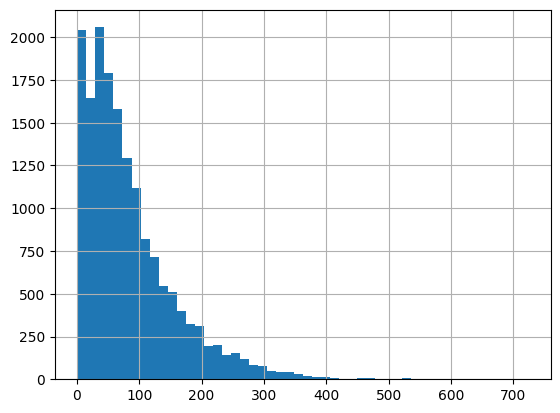

In [20]:
h3_count["pole_count"].hist(bins=50)

# x축 : h3 셀 하나에 들어있는 전력설비 개수 (pole_count)
# y축 : 그런 h3 셀이 몇 개 있는가

In [21]:
# H3 중심 좌표 생성

h3_count["center"] = h3_count["h3_id"].apply(
    lambda x: h3.cell_to_latlng(x)
)

h3_count["lat"] = h3_count["center"].apply(lambda x: x[0])
h3_count["lon"] = h3_count["center"].apply(lambda x: x[1])

In [22]:
# H3 육각형 Geometry 생성

h3_count["boundary"] = h3_count["h3_id"].apply(
    lambda x: h3.cell_to_boundary(x)
)

In [23]:
import folium

m = folium.Map(
    location=[37.8, 128.2],
    zoom_start=8,
    tiles="CartoDB positron"
)

for _, row in h3_count.iterrows():

    folium.Polygon(
        locations=row["boundary"],
        color="black",
        weight=0.3,
        fill=True,
        fill_opacity=0.5,
        popup=f"Pole Count: {row['pole_count']}"
    ).add_to(m)

#m

In [24]:
# 색상

import branca.colormap as cm

colormap = cm.linear.YlOrRd_09.scale(
    h3_count["pole_count"].min(),
    h3_count["pole_count"].max()
)

In [25]:
for _, row in h3_count.iterrows():

    folium.Polygon(
        locations=row["boundary"],
        color=None,
        fill=True,
        fill_color=colormap(row["pole_count"]),
        fill_opacity=0.7,
        popup=f"""
        Pole Count:
        {row['pole_count']}
        """
    ).add_to(m)

colormap.add_to(m)

#m

---

# NASA 열점 데이터 H3에 매핑
https://data.kma.go.kr/cmmn/main.do

In [26]:
fire_archive_df = pd.read_csv("나사 위성데이터_한국/fire_archive_SV-C2_760490.csv")
fire_archive_df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,37.48355,129.05582,298.86,0.47,0.4,2012-01-22,1731,SNPP,SNPP,n,2,267.73,1.16,N,2
1,37.48460,129.05043,308.56,0.47,0.4,2012-01-22,1731,SNPP,SNPP,n,2,272.14,2.78,N,2
2,37.48713,129.05696,306.35,0.47,0.4,2012-01-22,1731,SNPP,SNPP,n,2,270.78,1.34,N,2
3,37.42311,129.17606,303.27,0.48,0.4,2012-01-22,1731,SNPP,SNPP,n,2,270.01,1.19,N,2
4,37.42669,129.17734,301.31,0.48,0.4,2012-01-22,1731,SNPP,SNPP,n,2,270.12,1.19,N,2


In [27]:
fire_archive_df.tail()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
124716,35.42846,129.22026,327.04,0.51,0.41,2026-04-27,411,SNPP,SNPP,l,2,298.36,3.49,D,0
124717,36.02591,129.38524,332.27,0.49,0.40,2026-04-27,411,SNPP,SNPP,n,2,297.23,1.81,D,3
124718,35.13986,128.87697,331.74,0.54,0.42,2026-04-27,411,SNPP,SNPP,l,2,302.00,6.46,D,0
124719,35.13606,128.87811,327.38,0.54,0.42,2026-04-27,411,SNPP,SNPP,l,2,299.23,4.87,D,0
124720,35.24667,128.61980,330.08,0.55,0.43,2026-04-27,411,SNPP,SNPP,l,2,304.36,6.51,D,0


In [28]:
# 칼럼 필터링

fire_archive_df = fire_archive_df[
    [
        "latitude",     # 위도
        "longitude",    # 경도
        "acq_date",     # 감지 날짜
        "confidence",   # 탐지 신뢰도(low, nominal, high)
        "frp",          # 열 방출 강도(2↑ 약한불,오탐가능성, 50↑ 꽤 강한 화재 신호, 300↑ 매우 강한 화재 신호)
        "daynight",     # 낮or밤(D = 낮, N = 밤)
        "type"          # 열점 유형(0=산불, 농업 소각 등, 1=활화산, 2=공장 등, 3=해상탐지)
    ]
].copy()
fire_archive_df


,latitude,longitude,acq_date,confidence,frp,daynight,type
0,37.48355,129.05582,2012-01-22,n,1.16,N,2
1,37.48460,129.05043,2012-01-22,n,2.78,N,2
2,37.48713,129.05696,2012-01-22,n,1.34,N,2
3,37.42311,129.17606,2012-01-22,n,1.19,N,2
4,37.42669,129.17734,2012-01-22,n,1.19,N,2
...,...,...,...,...,...,...,...
124716,35.42846,129.22026,2026-04-27,l,3.49,D,0
124717,36.02591,129.38524,2026-04-27,n,1.81,D,3
124718,35.13986,128.87697,2026-04-27,l,6.46,D,0
124719,35.13606,128.87811,2026-04-27,l,4.87,D,0


In [29]:
# confidence = n or h
# frp >= 10
# type = 0 필터

fire_archive_filter_df = fire_archive_df[
    (fire_archive_df["frp"] >= 10)
    & (fire_archive_df["type"] == 0)
    & (fire_archive_df["confidence"].isin(["n", "h"]))
].copy()
fire_archive_filter_df

,latitude,longitude,acq_date,confidence,frp,daynight,type
93,35.04032,126.73033,2012-01-28,n,10.04,D,0
467,35.49845,128.48085,2012-02-20,n,11.13,D,0
479,36.96970,127.16096,2012-02-20,n,16.81,D,0
531,35.57951,127.38409,2012-02-23,n,19.16,D,0
532,35.57974,127.38790,2012-02-23,n,19.16,D,0
...,...,...,...,...,...,...,...
124043,35.67699,126.71116,2026-03-28,n,13.69,D,0
124044,35.10255,127.80817,2026-03-28,n,12.98,D,0
124045,35.67940,126.71885,2026-03-28,h,13.69,D,0
124189,36.99720,126.49351,2026-04-05,n,19.22,D,0


In [30]:
# FIRMS 열점 좌표를 H3 Resolution 8 격자로 변환
fire_archive_filter_df["h3_id"] = fire_archive_filter_df.apply(
    lambda row: h3.latlng_to_cell(row["latitude"], row["longitude"], 8),
    axis=1
)

# pole이 존재하는 H3 격자 목록
pole_h3_set = set(h3_count["h3_id"])

# pole이 있는 H3 격자 안에 들어온 FIRMS 열점만 필터링
fire_archive_filter_h3_df = fire_archive_filter_df[
    fire_archive_filter_df["h3_id"].isin(pole_h3_set)
].copy()

fire_archive_filter_h3_df = fire_archive_filter_h3_df.reset_index(drop=True)

# 강원도 H3 안에 찍힌 frp 10 이상의 열점, VIIRS S-NPP 375m 기준이므로 한 픽셀은 375m X 375m
# H3 안에 대략 5개의 열점이 들어갈 수 있음
fire_archive_filter_h3_df

,latitude,longitude,acq_date,confidence,frp,daynight,type,h3_id
0,37.34812,128.17050,2012-05-06,n,14.31,D,0,8830ee8093fffff
1,37.92622,128.72720,2013-03-08,n,11.09,D,0,8830ec399dfffff
2,37.26126,128.29329,2015-03-07,n,20.99,D,0,8830ee8c93fffff
3,37.26099,128.29095,2015-03-07,n,25.24,D,0,8830ee8c93fffff
4,37.23759,128.16060,2015-03-26,n,15.34,D,0,8830ee8f07fffff
...,...,...,...,...,...,...,...,...
160,37.27839,127.79237,2022-05-05,n,10.38,D,0,8830e16e03fffff
161,38.09533,128.56850,2022-12-26,n,15.15,N,0,8830ec06e3fffff
162,38.09167,128.56769,2022-12-26,n,32.43,N,0,8830ec06e3fffff
163,37.70680,128.99190,2025-08-20,n,10.16,D,0,8830e88309fffff


---

# 일별 위험점수를 위한 데이터
일별 위험점수 = (건조지수_d) × 0.3<br>+ (풍속지수_d) × 0.25<br>+ (산림비율) × 0.2<br>+ (과거화재밀도) × 0.15<br>+ (설비밀도) × 0.1

# 1. 건조지수_d
- 연속 무강수일수 x (100 - 최저습도) / 100 <br>

https://data.kma.go.kr/cmmn/main.do

In [31]:
# 계산을 위한 빈 df
daily_risk_df = pd.DataFrame()

In [32]:
# 데이터 - 지상 - 종관기상관측(ASOS) - 일 자료
# 기간이 길어서 둘로 나눠서 수집
ASOS_to2020_df = pd.read_csv("ASOS_to2020.csv", encoding="cp949")
ASOS_to2026_df = pd.read_csv("ASOS_to2026.csv", encoding="cp949")

In [33]:
ASOS_to2020_df.head()

,지점,지점명,일시,평균기온(°C),최저기온(°C),최고기온(°C),10분 최다 강수량(mm),1시간 최다강수량(mm),일강수량(mm),최대 순간 풍속(m/s),최대 풍속(m/s),평균 풍속(m/s),최소 상대습도(%),평균 상대습도(%)
0,90,속초,2012-01-22,-0.3,-5.3,2.9,NaN,NaN,NaN,9.4,6.2,2.7,28.0,47.5
1,90,속초,2012-01-23,-5.6,-8.9,-1.8,NaN,NaN,NaN,13.8,8.0,2.4,14.0,21.3
2,90,속초,2012-01-24,-4.9,-8.2,-1.7,NaN,NaN,NaN,13.1,8.1,3.6,13.0,21.1
3,90,속초,2012-01-25,-4.7,-7.9,-1.2,NaN,NaN,NaN,10.5,6.7,3.1,13.0,26.1
4,90,속초,2012-01-26,-1.0,-6.3,2.4,NaN,NaN,NaN,14.7,8.0,3.6,21.0,37.6


In [34]:
ASOS_to2026_df.head()

,지점,지점명,일시,평균기온(°C),최저기온(°C),최고기온(°C),10분 최다 강수량(mm),1시간 최다강수량(mm),일강수량(mm),최대 순간 풍속(m/s),최대 풍속(m/s),평균 풍속(m/s),최소 상대습도(%),평균 상대습도(%)
0,90,속초,2021-01-01,-2.9,-7.7,1.2,NaN,NaN,NaN,9.8,5.2,2.2,23.0,27.6
1,90,속초,2021-01-02,-2.5,-6.3,1.5,NaN,NaN,NaN,8.7,5.0,2.3,10.0,16.8
2,90,속초,2021-01-03,-2.5,-5.8,0.7,NaN,NaN,NaN,12.5,7.3,3.6,14.0,19.4
3,90,속초,2021-01-04,-0.9,-4.2,3.2,NaN,NaN,NaN,8.7,5.5,2.7,13.0,25.1
4,90,속초,2021-01-05,-3.2,-7.3,0.1,NaN,NaN,NaN,12.4,5.7,2.5,13.0,29.6


In [35]:
# 지점명 순서
ASOS_station_order = ASOS_to2026_df["지점명"].drop_duplicates().tolist()
print(ASOS_station_order)

['속초', '북춘천', '철원', '대관령', '춘천', '북강릉', '강릉', '동해', '원주', '영월', '인제', '홍천', '태백', '정선군']


In [36]:
# 두 파일 데이터 합쳐서 재정렬
ASOS_df = pd.concat(
    [ASOS_to2020_df, ASOS_to2026_df],
    ignore_index=True
)

ASOS_df["지점명"] = pd.Categorical(
    ASOS_df["지점명"],
    categories=ASOS_station_order,
    ordered=True
)

ASOS_df["일시"] = pd.to_datetime(ASOS_df["일시"])

ASOS_df = ASOS_df.sort_values(
    by=["지점명", "일시"],
    ascending=[True, True]
).reset_index(drop=True)

ASOS_df

,지점,지점명,일시,평균기온(°C),최저기온(°C),최고기온(°C),10분 최다 강수량(mm),1시간 최다강수량(mm),일강수량(mm),최대 순간 풍속(m/s),최대 풍속(m/s),평균 풍속(m/s),최소 상대습도(%),평균 상대습도(%)
0,90,속초,2012-01-22,-0.3,-5.3,2.9,NaN,NaN,NaN,9.4,6.2,2.7,28.0,47.5
1,90,속초,2012-01-23,-5.6,-8.9,-1.8,NaN,NaN,NaN,13.8,8.0,2.4,14.0,21.3
2,90,속초,2012-01-24,-4.9,-8.2,-1.7,NaN,NaN,NaN,13.1,8.1,3.6,13.0,21.1
3,90,속초,2012-01-25,-4.7,-7.9,-1.2,NaN,NaN,NaN,10.5,6.7,3.1,13.0,26.1
4,90,속초,2012-01-26,-1.0,-6.3,2.4,NaN,NaN,NaN,14.7,8.0,3.6,21.0,37.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71207,217,정선군,2026-04-23,10.0,3.9,17.0,NaN,NaN,NaN,14.0,6.7,2.6,21.0,43.0
71208,217,정선군,2026-04-24,12.6,-0.5,26.5,NaN,NaN,NaN,5.4,3.2,1.1,8.0,41.9
71209,217,정선군,2026-04-25,14.6,2.8,27.5,NaN,NaN,NaN,7.8,4.5,0.9,10.0,40.9
71210,217,정선군,2026-04-26,15.4,3.8,27.5,NaN,NaN,NaN,7.5,4.2,1.0,12.0,39.4


In [37]:
# NaN값을 0으로 치환
ASOS_df["일강수량(mm)"] = ASOS_df["일강수량(mm)"].fillna(0)

# 비가 안온날이면 True, 온날이면 False 후 "no_rain"에 생성
ASOS_df["no_rain"] = ASOS_df["일강수량(mm)"] == 0

# True의 수를 세고 False가 나오면 0부터 시작
ASOS_df["rain_group"] = (
    ASOS_df
    .groupby("지점명")["no_rain"]
    .transform(lambda x: (~x).cumsum())
)

ASOS_df["no_rain_days"] = (
    ASOS_df["no_rain"]
    .groupby([ASOS_df["지점명"], ASOS_df["rain_group"]])
    .cumsum()
)

# 건조지수 = 연속 무강수일수 × (100 - 최소 상대습도) / 100
ASOS_df["dry_index"] = (
    ASOS_df["no_rain_days"]
    * (100 - ASOS_df["최소 상대습도(%)"])
    / 100
)

# 풍속지수 = 일 최대 순간풍속 / 해당 지점의 평균풍속
ASOS_df["wind_index"] = (
    ASOS_df["최대 순간 풍속(m/s)"]
    / ASOS_df["평균 풍속(m/s)"]
)

ASOS_df[["지점명", "지점", "일시", "dry_index", "wind_index"]]

,지점명,지점,일시,dry_index,wind_index
0,속초,90,2012-01-22,0.72,3.481481
1,속초,90,2012-01-23,1.72,5.750000
2,속초,90,2012-01-24,2.61,3.638889
3,속초,90,2012-01-25,3.48,3.387097
4,속초,90,2012-01-26,3.95,4.083333
...,...,...,...,...,...
71207,정선군,217,2026-04-23,2.37,5.384615
71208,정선군,217,2026-04-24,3.68,4.909091
71209,정선군,217,2026-04-25,4.50,8.666667
71210,정선군,217,2026-04-26,5.28,7.500000


---

# 6월 19일 회의 이후 FWI 지표

## 1. 각 지점명 및 지점코드에 대한 위경도 지정

In [38]:
AWS_to2020_df = pd.read_csv("AWS_to2020.csv", encoding="cp949")
AWS_to2026_df = pd.read_csv("AWS_to2026.csv", encoding="cp949")

In [39]:
print(AWS_to2020_df["지점명"].nunique())
print(AWS_to2026_df["지점명"].nunique())
# 각 연도에서 지점명의 수가 차이가 나고있음

78
91


In [40]:
AWS_station_order = pd.concat([
    AWS_to2020_df["지점명"],
    AWS_to2026_df["지점명"]
]).drop_duplicates().tolist()
print(AWS_station_order)

['궁촌', '평창용산', '향로봉', '원통', '상서', '마현', '둔내', '삽당령', '구룡령', '간성', '해안', '사내', '설악동', '강현', '화촌', '주문진', '경포', '봉평', '평창', '신동', '원덕', '서석', '횡성', '임계', '김화', '죽정', '미시령', '화천', '양구', '기린', '팔봉', '내면', '진부', '청일', '영월주천', '북평', '연곡', '하장', '옥계', '상동', '신림', '안흥', '신남', '북산', '방산', '남산', '치악산', '부론', '양양영덕', '서화', '진부령', '오색', '대화', '양지', '외촌', '면온', '현내', '양양', '속초조양', '사북', '남이섬', '달방댐', '강릉성산', '강릉왕산', '평화', '간동', '임남', '춘천신북', '광덕산', '신기', '원주백운산', '동송', '설악산', '삼척', '문막', '도계', '스키점프', '철원장흥', '등봉', '동해심곡', '중앙', '강림', '매일', '우항', '서원', '공근', '학성', '강릉구정', '귀래', '하조대', '시동', '조침령']


In [41]:
# 두 파일 데이터 합쳐서 재정렬
AWS_df = pd.concat(
    [AWS_to2020_df, AWS_to2026_df],
    ignore_index=True
)

AWS_df["지점명"] = pd.Categorical(
    AWS_df["지점명"],
    categories=AWS_station_order,
    ordered=True
)

AWS_df["일시"] = pd.to_datetime(AWS_df["일시"])

AWS_df = AWS_df.sort_values(
    by=["지점명", "일시"],
    ascending=[True, True]
).reset_index(drop=True)

AWS_df

,지점,지점명,일시,평균기온(°C),일강수량(mm),최대 순간 풍속(m/s),평균 풍속(m/s)
0,310,궁촌,2012-01-22,2.3,0.5,10.8,3.1
1,310,궁촌,2012-01-23,-3.5,0.0,10.0,3.1
2,310,궁촌,2012-01-24,-4.3,0.0,11.2,2.7
3,310,궁촌,2012-01-25,-4.1,0.0,11.3,2.3
4,310,궁촌,2012-01-26,-1.8,0.0,9.9,1.8
...,...,...,...,...,...,...,...
398474,350,조침령,2026-04-23,7.6,0.0,8.2,1.8
398475,350,조침령,2026-04-24,8.1,0.0,6.0,1.2
398476,350,조침령,2026-04-25,13.8,0.0,7.3,1.4
398477,350,조침령,2026-04-26,15.5,0.0,8.0,2.8


In [42]:
# 지점코드 내역
station_codes = (
    pd.concat(
        [ASOS_df["지점"], AWS_df["지점"]],
        ignore_index=True
    )
    .drop_duplicates()
    .reset_index(drop=True)
)

station_codes

0       90
1       93
2       95
3      100
4      101
      ... 
102    346
103    347
104    348
105    349
106    350
Name: 지점, Length: 107, dtype: int64

In [43]:
from io import StringIO
'''
params = {
    "tm1": "20120122",
    "tm2": "20260427",
    "obs": "TA",
    "stn": "0",
    "disp": "0",
    "help": "0",
    "authKey": ASOS_API_KEY
}

response = requests.get(ASOS_url, params=params, timeout=600)
response.raise_for_status()

# #으로 시작하는 설명 행 제거 후 데이터만 읽기
data_lines = [
    line for line in response.text.splitlines()
    if line.strip() and not line.startswith("#")
]

ASOS_station_coord_df = pd.read_csv(
    StringIO("\n".join(data_lines)),
    sep=r"\s+",
    header=None,
    names=["TM", "STN", "LON", "LAT", "HT", "VAL"]
)

# 지점별 위경도만 남기기
ASOS_station_coord_df = (
    ASOS_station_coord_df[["STN", "LON", "LAT", "HT"]]
    .drop_duplicates(subset="STN")
    .reset_index(drop=True)
)

ASOS_station_coord_df
'''

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
C:\Users\dbsdn\AppData\Local\Temp\ipykernel_17312\401097864.py:24: SyntaxWarning: invalid escape sequence '\s'
  sep=r"\s+",


'\nparams = {\n    "tm1": "20120122",\n    "tm2": "20260427",\n    "obs": "TA",\n    "stn": "0",\n    "disp": "0",\n    "help": "0",\n    "authKey": ASOS_API_KEY\n}\n\nresponse = requests.get(ASOS_url, params=params, timeout=600)\nresponse.raise_for_status()\n\n# #으로 시작하는 설명 행 제거 후 데이터만 읽기\ndata_lines = [\n    line for line in response.text.splitlines()\n    if line.strip() and not line.startswith("#")\n]\n\nASOS_station_coord_df = pd.read_csv(\n    StringIO("\n".join(data_lines)),\n    sep=r"\\s+",\n    header=None,\n    names=["TM", "STN", "LON", "LAT", "HT", "VAL"]\n)\n\n# 지점별 위경도만 남기기\nASOS_station_coord_df = (\n    ASOS_station_coord_df[["STN", "LON", "LAT", "HT"]]\n    .drop_duplicates(subset="STN")\n    .reset_index(drop=True)\n)\n\nASOS_station_coord_df\n'

In [44]:
'''
params = {
    "tm1": "20120122",
    "tm2": "20260427",
    "obs": "rn_day",
    "stn": "0",
    "help": "0",
    "authKey": AWS_API_KEY
}

response = requests.get(AWS_url, params=params, timeout=600)
response.raise_for_status()

# #으로 시작하는 설명 행 제거 후 데이터만 읽기
data_lines = [
    line for line in response.text.splitlines()
    if line.strip() and not line.startswith("#")
]

AWS_station_coord_df = pd.read_csv(
    StringIO("\n".join(data_lines)),
    sep=",",
    header=None,
    usecols=range(6),
    names=["TM", "STN", "LON", "LAT", "HT", "VAL"]
)

AWS_station_coord_df = (
    AWS_station_coord_df[["STN", "LON", "LAT", "HT"]]
    .drop_duplicates(subset="STN")
    .reset_index(drop=True)
)

AWS_station_coord_df
'''

'\nparams = {\n    "tm1": "20120122",\n    "tm2": "20260427",\n    "obs": "rn_day",\n    "stn": "0",\n    "help": "0",\n    "authKey": AWS_API_KEY\n}\n\nresponse = requests.get(AWS_url, params=params, timeout=600)\nresponse.raise_for_status()\n\n# #으로 시작하는 설명 행 제거 후 데이터만 읽기\ndata_lines = [\n    line for line in response.text.splitlines()\n    if line.strip() and not line.startswith("#")\n]\n\nAWS_station_coord_df = pd.read_csv(\n    StringIO("\n".join(data_lines)),\n    sep=",",\n    header=None,\n    usecols=range(6),\n    names=["TM", "STN", "LON", "LAT", "HT", "VAL"]\n)\n\nAWS_station_coord_df = (\n    AWS_station_coord_df[["STN", "LON", "LAT", "HT"]]\n    .drop_duplicates(subset="STN")\n    .reset_index(drop=True)\n)\n\nAWS_station_coord_df\n'

In [45]:
# 응답시간이 너무 길어서 추출 후 사용
'''
ASOS_station_coord_df.to_csv(
    "ASOS_station_coord.csv",
    index=False,
    encoding="utf-8-sig"
)

AWS_station_coord_df.to_csv(
    "AWS_station_coord.csv",
    index=False,
    encoding="utf-8-sig"
)
'''

'\nASOS_station_coord_df.to_csv(\n    "ASOS_station_coord.csv",\n    index=False,\n    encoding="utf-8-sig"\n)\n\nAWS_station_coord_df.to_csv(\n    "AWS_station_coord.csv",\n    index=False,\n    encoding="utf-8-sig"\n)\n'

In [46]:
ASOS_station_coord_df = pd.read_csv("ASOS_station_coord.csv")
AWS_station_coord_df = pd.read_csv("AWS_station_coord.csv")
print(ASOS_station_coord_df.head())
print(AWS_station_coord_df.head())

   STN        LON       LAT      HT
0   90  128.56473  38.25085   17.53
1   93  127.75443  37.94738   95.78
2   95  127.30420  38.14787  155.48
3   98  127.06070  37.90188  115.62
4   99  126.76648  37.88589   30.59
   STN        LON       LAT      HT
0   90  128.56472  38.25085   18.06
1   92  128.66298  38.05903   75.40
2   95  127.30420  38.14787  155.48
3   96  131.86983  37.23952   96.15
4   98  127.06069  37.90186  109.06


In [47]:
station_coord_df = (
    pd.concat(
        [ASOS_station_coord_df, AWS_station_coord_df],
        ignore_index=True
    )
    .drop_duplicates(subset="STN", keep="first")
    .reset_index(drop=True)
)

station_coord_df

,STN,LON,LAT,HT
0,90,128.56473,38.25085,17.53
1,93,127.75443,37.94738,95.78
2,95,127.30420,38.14787,155.48
3,98,127.06070,37.90188,115.62
4,99,126.76648,37.88589,30.59
...,...,...,...,...
732,990,126.23050,33.31822,77.67
733,991,128.44562,35.80279,27.50
734,992,128.44640,35.90620,35.50
735,349,127.84308,37.59997,275.00


In [48]:
# ASOS와 AWS에 존재하는 지점코드 행만 출력
station_coord_filtered_df = (
    station_codes.to_frame(name="STN")
    .merge(
        station_coord_df[["STN", "LON", "LAT"]],
        on="STN",
        how="left"
    )
)

station_coord_filtered_df

,STN,LON,LAT
0,90,128.56473,38.25085
1,93,127.75443,37.94738
2,95,127.30420,38.14787
3,100,128.71834,37.67713
4,101,127.73570,37.90262
...,...,...,...
102,346,NaN,NaN
103,347,NaN,NaN
104,348,NaN,NaN
105,349,127.84308,37.59997


In [49]:
print(station_coord_filtered_df.isna().sum())

STN     0
LON    13
LAT    13
dtype: int64


In [50]:
# 누락된 번호 추출
missing_stn = (
    station_codes[
        ~station_codes.isin(station_coord_df["STN"])
    ]
    .reset_index(drop=True)
)

missing_stn.tolist()

[338, 332, 333, 334, 335, 336, 337, 339, 340, 345, 346, 347, 348]

In [51]:
# 누락 번호 찾기

import time
'''
obs_list = [
    "rn_day", "ta_max", "ta_max_dif", "ta_max_min",
    "ta_min", "ta_min_dif", "ws_max", "ws_ins_max",
    "sd_tot_max", "sd_day_max"
]

# 누락 지점별 첫 관측일
missing_query_df = (
    AWS_df[AWS_df["지점"].isin(missing_stn)]
    .groupby("지점", as_index=False)["일시"]
    .max()
)

availability_list = []

for stn, tm in missing_query_df.itertuples(index=False):
    for obs in obs_list:
        params = {
            "tm1": tm.strftime("%Y%m%d"),
            "tm2": tm.strftime("%Y%m%d"),
            "obs": obs,
            "stn": str(stn),
            "help": "0",
            "authKey": AWS_API_KEY
        }

        response = requests.get(AWS_url, params=params, timeout=60)
        response.raise_for_status()

        data_lines = [
            line for line in response.text.splitlines()
            if line.strip() and not line.startswith("#")
        ]

        availability_list.append({
            "STN": stn,
            "일시": tm,
            "obs": obs,
            "available": bool(data_lines)
        })

        time.sleep(0.1)

obs_available_df = pd.DataFrame(availability_list)

obs_available_df[obs_available_df["available"]]
'''

'\nobs_list = [\n    "rn_day", "ta_max", "ta_max_dif", "ta_max_min",\n    "ta_min", "ta_min_dif", "ws_max", "ws_ins_max",\n    "sd_tot_max", "sd_day_max"\n]\n\n# 누락 지점별 첫 관측일\nmissing_query_df = (\n    AWS_df[AWS_df["지점"].isin(missing_stn)]\n    .groupby("지점", as_index=False)["일시"]\n    .max()\n)\n\navailability_list = []\n\nfor stn, tm in missing_query_df.itertuples(index=False):\n    for obs in obs_list:\n        params = {\n            "tm1": tm.strftime("%Y%m%d"),\n            "tm2": tm.strftime("%Y%m%d"),\n            "obs": obs,\n            "stn": str(stn),\n            "help": "0",\n            "authKey": AWS_API_KEY\n        }\n\n        response = requests.get(AWS_url, params=params, timeout=60)\n        response.raise_for_status()\n\n        data_lines = [\n            line for line in response.text.splitlines()\n            if line.strip() and not line.startswith("#")\n        ]\n\n        availability_list.append({\n            "STN": stn,\n            "일시": tm,\n         

In [52]:
# 모두 찾을 수 있는 obs 검색 -> rn_day
'''
coord_query_df = (
    obs_available_df[obs_available_df["available"]]
    .sort_values(["STN", "obs"])
    .drop_duplicates(subset="STN")
    [["STN", "일시", "obs"]]
    .reset_index(drop=True)
)

coord_query_df
'''

'\ncoord_query_df = (\n    obs_available_df[obs_available_df["available"]]\n    .sort_values(["STN", "obs"])\n    .drop_duplicates(subset="STN")\n    [["STN", "일시", "obs"]]\n    .reset_index(drop=True)\n)\n\ncoord_query_df\n'

In [53]:
# rn_day로 재검색
'''
missing_stn_text = ":".join(coord_query_df["STN"].astype(str))

params = {
    "tm1": "20260427",
    "tm2": "20260427",
    "obs": "rn_day",
    "stn": missing_stn_text,
    "help": "0",
    "authKey": AWS_API_KEY
}

response = requests.get(AWS_url, params=params, timeout=60)
response.raise_for_status()

data_lines = [
    line for line in response.text.splitlines()
    if line.strip() and not line.startswith("#")
]

missing_coord_df = pd.read_csv(
    StringIO("\n".join(data_lines)),
    sep=",",
    header=None,
    usecols=range(6),
    names=["TM", "STN", "LON", "LAT", "HT", "VAL"]
)[["STN", "LON", "LAT", "HT"]]

missing_coord_df
'''

'\nmissing_stn_text = ":".join(coord_query_df["STN"].astype(str))\n\nparams = {\n    "tm1": "20260427",\n    "tm2": "20260427",\n    "obs": "rn_day",\n    "stn": missing_stn_text,\n    "help": "0",\n    "authKey": AWS_API_KEY\n}\n\nresponse = requests.get(AWS_url, params=params, timeout=60)\nresponse.raise_for_status()\n\ndata_lines = [\n    line for line in response.text.splitlines()\n    if line.strip() and not line.startswith("#")\n]\n\nmissing_coord_df = pd.read_csv(\n    StringIO("\n".join(data_lines)),\n    sep=",",\n    header=None,\n    usecols=range(6),\n    names=["TM", "STN", "LON", "LAT", "HT", "VAL"]\n)[["STN", "LON", "LAT", "HT"]]\n\nmissing_coord_df\n'

In [54]:
missing_coord_df = pd.read_csv("AWS_missing_station_coord.csv")

In [55]:
# 누락 13개 좌표를 AWS 좌표 테이블에 추가
AWS_station_coord_df = (
    pd.concat(
        [AWS_station_coord_df, missing_coord_df],
        ignore_index=True
    )
    .drop_duplicates(subset="STN", keep="first")
    .reset_index(drop=True)
)

# ASOS 우선으로 전체 좌표 테이블 생성
station_coord_df = (
    pd.concat(
        [ASOS_station_coord_df, AWS_station_coord_df],
        ignore_index=True
    )
    .drop_duplicates(subset="STN", keep="first")
    .reset_index(drop=True)
)

# 실제 날씨 데이터에 존재하는 지점코드만 남김
station_coord_filtered_df = (
    station_codes.to_frame(name="STN")
    .merge(
        station_coord_df[["STN", "LON", "LAT"]],
        on="STN",
        how="left"
    )
)

print(station_coord_filtered_df.isna().sum())

STN    0
LON    0
LAT    0
dtype: int64


In [56]:
print(station_coord_filtered_df)

     STN        LON       LAT
0     90  128.56473  38.25085
1     93  127.75443  37.94738
2     95  127.30420  38.14787
3    100  128.71834  37.67713
4    101  127.73570  37.90262
..   ...        ...       ...
102  346  128.89722  37.71199
103  347  127.85685  37.22755
104  348  128.71678  38.02572
105  349  127.84308  37.59997
106  350  128.49556  37.99534

[107 rows x 3 columns]


In [57]:
# 결과의 위경도 칼럼을 ASOS_df, AWS_df에 맞춰 추가
station_coord_merge_df = station_coord_filtered_df.rename(
    columns={"STN": "지점"}
)

ASOS_df = ASOS_df.merge(
    station_coord_merge_df,
    on="지점",
    how="left",
    validate="many_to_one"
)

AWS_df = AWS_df.merge(
    station_coord_merge_df,
    on="지점",
    how="left",
    validate="many_to_one"
)

In [58]:
print(ASOS_df)

        지점  지점명         일시  평균기온(°C)  최저기온(°C)  최고기온(°C)  10분 최다 강수량(mm)  \
0       90   속초 2012-01-22      -0.3      -5.3       2.9             NaN   
1       90   속초 2012-01-23      -5.6      -8.9      -1.8             NaN   
2       90   속초 2012-01-24      -4.9      -8.2      -1.7             NaN   
3       90   속초 2012-01-25      -4.7      -7.9      -1.2             NaN   
4       90   속초 2012-01-26      -1.0      -6.3       2.4             NaN   
...    ...  ...        ...       ...       ...       ...             ...   
71207  217  정선군 2026-04-23      10.0       3.9      17.0             NaN   
71208  217  정선군 2026-04-24      12.6      -0.5      26.5             NaN   
71209  217  정선군 2026-04-25      14.6       2.8      27.5             NaN   
71210  217  정선군 2026-04-26      15.4       3.8      27.5             NaN   
71211  217  정선군 2026-04-27      13.9       5.2      24.6             0.2   

       1시간 최다강수량(mm)  일강수량(mm)  최대 순간 풍속(m/s)  ...  평균 풍속(m/s)  최소 상대습도(%)  \
0        

In [59]:
print(AWS_df)

         지점  지점명         일시  평균기온(°C)  일강수량(mm)  최대 순간 풍속(m/s)  평균 풍속(m/s)  \
0       310   궁촌 2012-01-22       2.3       0.5           10.8         3.1   
1       310   궁촌 2012-01-23      -3.5       0.0           10.0         3.1   
2       310   궁촌 2012-01-24      -4.3       0.0           11.2         2.7   
3       310   궁촌 2012-01-25      -4.1       0.0           11.3         2.3   
4       310   궁촌 2012-01-26      -1.8       0.0            9.9         1.8   
...     ...  ...        ...       ...       ...            ...         ...   
398474  350  조침령 2026-04-23       7.6       0.0            8.2         1.8   
398475  350  조침령 2026-04-24       8.1       0.0            6.0         1.2   
398476  350  조침령 2026-04-25      13.8       0.0            7.3         1.4   
398477  350  조침령 2026-04-26      15.5       0.0            8.0         2.8   
398478  350  조침령 2026-04-27       9.4       4.5            6.2         1.2   

              LON       LAT  
0       129.26472  37.32471  
1  

In [60]:
# 지점정보만 중복없이 추출
ASOS_distinct_df = (
    ASOS_df[["지점", "지점명", "LON", "LAT"]]
    .drop_duplicates(subset="지점")
    .reset_index(drop=True)
)

AWS_distinct_df = (
    AWS_df[["지점", "지점명", "LON", "LAT"]]
    .drop_duplicates(subset="지점")
    .reset_index(drop=True)
)

In [61]:
print(ASOS_distinct_df.head())
print(AWS_distinct_df.head())

    지점  지점명        LON       LAT
0   90   속초  128.56473  38.25085
1   93  북춘천  127.75443  37.94738
2   95   철원  127.30420  38.14787
3  100  대관령  128.71834  37.67713
4  101   춘천  127.73570  37.90262
    지점   지점명        LON       LAT
0  310    궁촌  129.26472  37.32471
1  318  평창용산  128.67040  37.64340
2  320   향로봉  128.31372  38.33101
3  321    원통  128.19630  38.11470
4  322    상서  127.66263  38.20067


In [62]:
# AWS에는 습도 정보를 추출할 수 없으므로 ASOS에 있는 지점 중 가장 가까운 곳의 습도를 AWS 지점에 지정
aws_lat = np.radians(AWS_distinct_df["LAT"].to_numpy())
aws_lon = np.radians(AWS_distinct_df["LON"].to_numpy())

asos_lat = np.radians(ASOS_distinct_df["LAT"].to_numpy())
asos_lon = np.radians(ASOS_distinct_df["LON"].to_numpy())

# AWS 지점별 ASOS 지점까지의 haversine 거리 계산
dlat = aws_lat[:, None] - asos_lat
dlon = aws_lon[:, None] - asos_lon

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(aws_lat[:, None])
    * np.cos(asos_lat)
    * np.sin(dlon / 2) ** 2
)

distance = 2 * 6371 * np.arcsin(np.sqrt(a))

# 가장 가까운 ASOS 지점번호 추가
nearest_asos_idx = distance.argmin(axis=1)

AWS_distinct_df["ASOS_station"] = (
    ASOS_distinct_df.iloc[nearest_asos_idx]["지점"]
    .to_numpy()
)

# AWS 지점코드별 가장 가까운 ASOS 지점번호 붙이기
AWS_df = AWS_df.merge(
    AWS_distinct_df[["지점", "ASOS_station"]],
    on="지점",
    how="left",
    validate="many_to_one"
)

# ASOS의 날짜별 평균 상대습도 준비
asos_humidity_df = ASOS_df[
    ["지점", "일시", "평균 상대습도(%)"]
].rename(columns={"지점": "ASOS_station"})

# AWS 지점의 매칭 ASOS + 날짜 기준으로 평균 상대습도 붙이기
AWS_df = AWS_df.merge(
    asos_humidity_df,
    on=["ASOS_station", "일시"],
    how="left",
    validate="many_to_one"
)

## 2. FWI 지표 계산하기

In [63]:
# 두 최종 ASOS, AWS df 합치기
fwi_input_cols = [
    "지점",
    "지점명",
    "일시",
    "LON",
    "LAT",
    "평균기온(°C)",
    "평균 상대습도(%)",
    "평균 풍속(m/s)",
    "일강수량(mm)"
]

ASOS_fwi_df = ASOS_df[fwi_input_cols].copy()
ASOS_fwi_df["station_type"] = "ASOS"

AWS_fwi_df = AWS_df[fwi_input_cols].copy()
AWS_fwi_df["station_type"] = "AWS"

fwi_df = (
    pd.concat([ASOS_fwi_df, AWS_fwi_df], ignore_index=True)
    .sort_values(["station_type", "지점", "일시"])
    .reset_index(drop=True)
)

In [64]:
import math

# 강원도는 북위 30도 이상이므로 해당 월별 보정값 사용
dmc_day_length = [6.5, 7.5, 9.0, 12.8, 13.9, 13.9, 12.4, 10.9, 9.4, 8.0, 7.0, 6.0]
dc_drying_factor = [-1.6, -1.6, -1.6, 0.9, 3.8, 5.8, 6.4, 5.0, 2.4, 0.4, -1.6, -1.6]


def add_fwi_columns(group):
    group = group.sort_values("일시").copy()

    ffmc_prev = 85.0
    dmc_prev = 6.0
    dc_prev = 15.0

    ffmc_list, dmc_list, dc_list = [], [], []
    isi_list, bui_list, fwi_list = [], [], []

    for _, row in group.iterrows():
        temp = row["평균기온(°C)"]
        rh = row["평균 상대습도(%)"]
        wind = row["평균 풍속(m/s)"] * 3.6  # km/h 변환
        rain = row["일강수량(mm)"]

        if pd.isna(temp) or pd.isna(rh) or pd.isna(wind):
            ffmc_list.append(np.nan)
            dmc_list.append(np.nan)
            dc_list.append(np.nan)
            isi_list.append(np.nan)
            bui_list.append(np.nan)
            fwi_list.append(np.nan)
            continue

        rain = 0 if pd.isna(rain) else max(rain, 0)
        month_idx = row["일시"].month - 1

        # FFMC
        mo = 147.2 * (101 - ffmc_prev) / (59.5 + ffmc_prev)

        if rain > 0.5:
            rf = rain - 0.5

            if mo > 150:
                mo += (
                    42.5 * rf * math.exp(-100 / (251 - mo))
                    * (1 - math.exp(-6.93 / rf))
                    + 0.0015 * (mo - 150) ** 2 * math.sqrt(rf)
                )
            else:
                mo += (
                    42.5 * rf * math.exp(-100 / (251 - mo))
                    * (1 - math.exp(-6.93 / rf))
                )

            mo = min(mo, 250)

        ed = (
            0.942 * rh ** 0.679
            + 11 * math.exp((rh - 100) / 10)
            + 0.18 * (21.1 - temp) * (1 - math.exp(-0.115 * rh))
        )

        if mo < ed:
            ew = (
                0.618 * rh ** 0.753
                + 10 * math.exp((rh - 100) / 10)
                + 0.18 * (21.1 - temp) * (1 - math.exp(-0.115 * rh))
            )

            if mo < ew:
                kl = (
                    0.424 * (1 - (rh / 100) ** 1.7)
                    + 0.0694 * math.sqrt(wind) * (1 - (rh / 100) ** 8)
                )
                kw = kl * 0.581 * math.exp(0.0365 * temp)
                mo = ew - (ew - mo) * 10 ** (-kw)
        else:
            kl = (
                0.424 * (1 - ((100 - rh) / 100) ** 1.7)
                + 0.0694 * math.sqrt(wind) * (1 - ((100 - rh) / 100) ** 8)
            )
            kw = kl * 0.581 * math.exp(0.0365 * temp)
            mo = ed + (mo - ed) * 10 ** (-kw)

        ffmc = 59.5 * (250 - mo) / (147.2 + mo)
        ffmc = min(max(ffmc, 0), 101)

        # DMC
        dmc = dmc_prev

        if rain > 1.5:
            rw = 0.92 * rain - 1.27
            wmi = 20 + math.exp(5.6348 - dmc / 43.43)

            if dmc <= 33:
                b = 100 / (0.5 + 0.3 * dmc)
            elif dmc <= 65:
                b = 14 - 1.3 * math.log(dmc)
            else:
                b = 6.2 * math.log(dmc) - 17.2

            wmr = wmi + 1000 * rw / (48.77 + b * rw)
            dmc = max(0, 244.72 - 43.43 * math.log(wmr - 20))

        k = 1.894 * (temp + 1.1) * (100 - rh) * dmc_day_length[month_idx] * 1e-6
        dmc = max(0, dmc + 100 * max(k, 0))

        # DC
        dc = dc_prev

        if rain > 2.8:
            rw = 0.83 * rain - 1.27
            smi = 800 * math.exp(-dc / 400)
            dc = max(0, dc - 400 * math.log(1 + 3.937 * rw / smi))

        v = 0.36 * (temp + 2.8) + dc_drying_factor[month_idx]
        dc = max(0, dc + 0.5 * max(v, 0))

        # ISI
        mo_isi = 147.2 * (101 - ffmc) / (59.5 + ffmc)
        ff = 91.9 * math.exp(-0.1386 * mo_isi) * (1 + mo_isi ** 5.31 / 4.93e7)
        fw = math.exp(0.05039 * wind)
        isi = 0.208 * fw * ff

        # BUI
        # BUI
        denom = dmc + 0.4 * dc

        if denom == 0:
            bui = 0
        elif dmc <= 0.4 * dc:
            bui = (0.8 * dmc * dc) / denom
        else:
            bui = dmc - (
                1 - (0.8 * dc) / denom
            ) * (0.92 + (0.0114 * dmc) ** 1.7)

        bui = max(bui, 0)

        # FWI
        if bui <= 80:
            fd = 0.626 * bui ** 0.809 + 2
        else:
            fd = 1000 / (25 + 108.64 * math.exp(-0.023 * bui))

        b = 0.1 * isi * fd
        fwi = b if b <= 1 else math.exp(2.72 * (0.434 * math.log(b)) ** 0.647)

        ffmc_list.append(ffmc)
        dmc_list.append(dmc)
        dc_list.append(dc)
        isi_list.append(isi)
        bui_list.append(bui)
        fwi_list.append(fwi)

        ffmc_prev, dmc_prev, dc_prev = ffmc, dmc, dc

    group["FFMC"] = ffmc_list
    group["DMC"] = dmc_list
    group["DC"] = dc_list
    group["ISI"] = isi_list
    group["BUI"] = bui_list
    group["FWI"] = fwi_list

    return group


fwi_df = (
    pd.concat(
        [
            add_fwi_columns(group)
            for _, group in fwi_df.groupby(
                ["station_type", "지점"],
                sort=False
            )
        ],
        ignore_index=True
    )
    .sort_values(["station_type", "지점", "일시"])
    .reset_index(drop=True)
)

In [65]:
# fwi_df의 칼럼명
print(fwi_df.columns.tolist())

['지점', '지점명', '일시', 'LON', 'LAT', '평균기온(°C)', '평균 상대습도(%)', '평균 풍속(m/s)', '일강수량(mm)', 'station_type', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']


In [66]:
print(fwi_df.head())

   지점 지점명         일시        LON       LAT  평균기온(°C)  평균 상대습도(%)  평균 풍속(m/s)  \
0  90  속초 2012-01-22  128.56473  38.25085      -0.3        47.5         2.7   
1  90  속초 2012-01-23  128.56473  38.25085      -5.6        21.3         2.4   
2  90  속초 2012-01-24  128.56473  38.25085      -4.9        21.1         3.6   
3  90  속초 2012-01-25  128.56473  38.25085      -4.7        26.1         3.1   
4  90  속초 2012-01-26  128.56473  38.25085      -1.0        37.6         3.6   

   일강수량(mm) station_type       FFMC       DMC    DC       ISI       BUI  \
0       0.0         ASOS  85.047707  6.051706  15.0  3.461652  6.047714   
1       0.0         ASOS  86.220930  6.051706  15.0  3.860773  6.047714   
2       0.0         ASOS  87.210597  6.051706  15.0  5.522904  6.047714   
3       0.0         ASOS  87.510078  6.051706  15.0  5.264317  6.047714   
4       0.0         ASOS  87.558613  6.059388  15.0  5.804251  6.054805   

        FWI  
0  2.692226  
1  3.094906  
2  4.636106  
3  4.407717  
4  4

In [67]:
# 지점별로 fwi의 상위 10%의 평균. ASOS와 AWS가 겹치면 ASOS 데이터를 사용
station_fwi_by_type_df = (
    fwi_df
    .groupby(["station_type", "지점", "지점명"], as_index=False)
    .agg(
        LON=("LON", "first"),
        LAT=("LAT", "first"),
        fwi_top10per_mean=(
            "FWI",
            lambda x: x[x >= x.quantile(0.9)].mean()
        )
    )
)

station_fwi_top10per_mean_df = (
    station_fwi_by_type_df
    .assign(
        priority=lambda df: df["station_type"].map(
            {"ASOS": 0, "AWS": 1}
        )
    )
    .sort_values(["지점", "priority"])
    .drop_duplicates(subset="지점", keep="first")
    [["지점", "지점명", "LON", "LAT", "fwi_top10per_mean"]]
    .reset_index(drop=True)
)

station_fwi_top10per_mean_df

,지점,지점명,LON,LAT,fwi_top10per_mean
0,90,속초,128.56473,38.25085,11.468410
1,93,북춘천,127.75443,37.94738,8.403888
2,95,철원,127.30420,38.14787,7.961664
3,100,대관령,128.71834,37.67713,7.631270
4,101,춘천,127.73570,37.90262,8.770057
...,...,...,...,...,...
102,877,문막,127.80480,37.31340,11.488137
103,878,도계,129.09608,37.22379,8.400669
104,879,스키점프,128.67940,37.66100,8.470502
105,970,철원장흥,127.25024,38.20160,7.066877


## 3. pole에 배정

In [68]:
from sklearn.neighbors import BallTree
import numpy as np

# 최근접 지점 탐색용 좌표: BallTree는 [위도, 경도] 순서의 라디안 값을 사용
station_coords = np.radians(
    station_fwi_top10per_mean_df[["LAT", "LON"]].to_numpy()
)

pole_coords = np.radians(
    elec_df[["lat", "lon"]].to_numpy()
)

# 107개 지점으로 최근접 탐색 트리 생성
tree = BallTree(station_coords, metric="haversine")

# 모든 pole에 대해 가장 가까운 지점 1개 탐색
_, nearest_idx = tree.query(pole_coords, k=1)

nearest_station_df = (
    station_fwi_top10per_mean_df
    .iloc[nearest_idx.ravel()]
    .reset_index(drop=True)
)

# elec_df에 배정 지점 정보 추가
elec_df["배정지점"] = nearest_station_df["지점"].to_numpy()
elec_df["배정지점명"] = nearest_station_df["지점명"].to_numpy()
elec_df["fwi_top10per_mean"] = (
    nearest_station_df["fwi_top10per_mean"].to_numpy()
)

elec_df

,pole_id,lon,lat,h3_id,배정지점,배정지점명,fwi_top10per_mean
0,0,127.618392,37.732192,8830e10689fffff,588,남산,7.659102
1,1,127.617858,37.732002,8830e10689fffff,588,남산,7.659102
2,2,127.617349,37.731836,8830e10689fffff,588,남산,7.659102
3,3,127.616804,37.731666,8830e10689fffff,588,남산,7.659102
4,4,127.616286,37.731509,8830e10689fffff,588,남산,7.659102
...,...,...,...,...,...,...,...
1387826,1387826,128.716098,38.024719,8830ec3a9dfffff,348,하조대,12.422516
1387827,1387827,128.716515,38.024432,8830ec3a9dfffff,348,하조대,12.422516
1387828,1387828,128.716938,38.024129,8830ec3a9dfffff,348,하조대,12.422516
1387829,1387829,128.717348,38.023796,8830ec3a9dfffff,348,하조대,12.422516


In [70]:
'''
elec_df.to_csv(
    "elec_fwi.csv",
    index=False,
    encoding="utf-8-sig"
)
'''

'\nelec_df.to_csv(\n    "elec_fwi.csv",\n    index=False,\n    encoding="utf-8-sig"\n)\n'